In [1]:
# Mempersiapkan tools yang akan di gunakan - import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler

# 1.Import Data

In [56]:
# Insert Amazon Sales Data.
df_rf = pd.read_csv("Downloads/Amazon Sales Data (ihsan &rafif).csv")
df_rf.head(5)

# Membuat dataframe (df_rf) dengan mengimpor dataset yang akan digunakan untuk proses analisis.
# Dataset yang digunakan berupa file berformat .csv yang disimpan secara lokal, kemudian dipanggil menggunakan library pandas.

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending


# 2.Eksplorasi Data

In [3]:
# Eksplorasi Data 1, .head() berfungsi untuk menampilakan dataset (melihat struktur data dan atribut yang tersedia). 
df_rf.head(10)

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending
5,ORD0006,14-03-25,T-Shirt,Clothing,20,1,20,John Doe,Dallas,Credit Card,Pending
6,ORD0007,18-03-25,Smartwatch,Electronics,150,4,600,Emma Clark,Houston,PayPal,Completed
7,ORD0008,02-03-25,Smartphone,Electronics,500,1,500,Sophia Miller,Miami,PayPal,Completed
8,ORD0009,08-03-25,T-Shirt,Clothing,20,3,60,Sophia Miller,Boston,PayPal,Completed
9,ORD0010,12-03-25,Smartphone,Electronics,500,1,500,Emily Johnson,San Francisco,Credit Card,Cancelled


In [4]:
# Eksplorasi Data 2, 
# .info() berfungsi untuk menampilakan informasi umum dataset (umlah data, nama atribut/kolom, tipe data, serta jumlah nilai non-null pada setiap atribut).
print("===== INFO DATAFRAME =====")
df_rf.info()

===== INFO DATAFRAME =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           250 non-null    object
 1   Date               250 non-null    object
 2   Product            250 non-null    object
 3   Category           250 non-null    object
 4   Price              250 non-null    int64 
 5   Quantity           250 non-null    int64 
 6   Total Sales        250 non-null    int64 
 7   Customer Name      250 non-null    object
 8   Customer Location  250 non-null    object
 9   Payment Method     250 non-null    object
 10  Status             250 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.6+ KB


In [5]:
# Eksplorasi Data 3
# .describe() digunakan untuk menampilkan statistik deskriptif pada atribut numerik (mean, standar deviasi, nilai minimum, maksimum, serta kuartil data).
print("\n===== DESCRIPTIVE STATISTICS =====")
df_rf.describe().round(1) # .round berfungsi untuk membulatkan angka menjadi 1 digit di belakang koma.


===== DESCRIPTIVE STATISTICS =====


,Price,Quantity,Total Sales
count,250.0,250.0,250.0
mean,343.6,2.9,975.4
std,380.6,1.4,1252.1
min,15.0,1.0,15.0
25%,40.0,2.0,100.0
50%,150.0,3.0,400.0
75%,600.0,4.0,1500.0
max,1200.0,5.0,6000.0


In [6]:
# Eksplorasi Data 4
# .shape digunakan untuk menampilkan dimensi dataset, yaitu jumlah baris (rows) dan jumlah kolom (columns) yang terdapat dalam dataset.
row, col = df_rf.shape
print(f"Terdapat {row} Baris dan {col} Kolom")

Terdapat 250 Baris dan 11 Kolom


In [7]:
# Eksplorasi Data 5
# Melakukan pengecekan duplicate data dan missing values
# untuk mengetahui kualitas data sebelum dilakukan preprocessing lebih lanjut.

# Mengecek jumlah data duplikat
duplicate_checking = df_rf.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_checking}")

# Mengecek jumlah missing values pada setiap kolom
missing_values_checking = df_rf.isnull().sum()
print("\nJumlah missing values pada setiap kolom:")
print(missing_values_checking)

Jumlah data duplikat: 0

Jumlah missing values pada setiap kolom:
Order ID             0
Date                 0
Product              0
Category             0
Price                0
Quantity             0
Total Sales          0
Customer Name        0
Customer Location    0
Payment Method       0
Status               0
dtype: int64


In [8]:
# Eksplorasi Data 6
# .dtypes digunakan untuk mengidentifikasi tipe data pada setiap atribut/kolom dalam dataset.
df_rf.dtypes

Order ID             object
Date                 object
Product              object
Category             object
Price                 int64
Quantity              int64
Total Sales           int64
Customer Name        object
Customer Location    object
Payment Method       object
Status               object
dtype: object

# Cek distribusi data (visualisasi histogram)

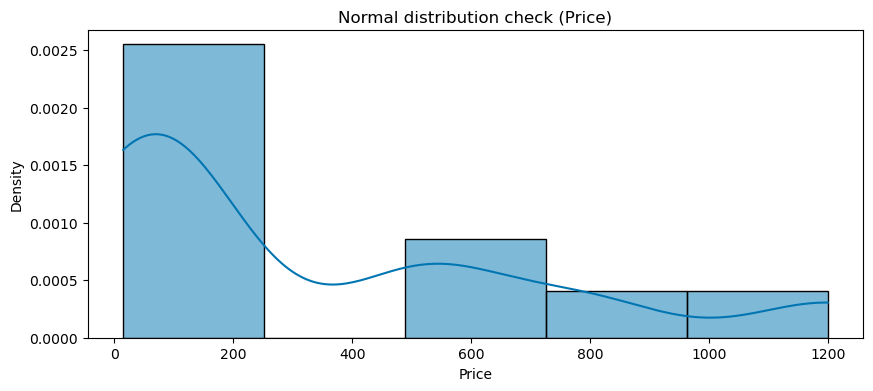

In [9]:
# Eksplorasi Data 7a
# Visualisasi distribusi data numerik (Price)
# menggunakan histogram untuk melihat pola persebaran data dan mengidentifikasi apakah distribusi cenderung normal atau tidak.
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,4))

sns.histplot(df_rf["Price"], bins=5, kde=True, stat="density", color="#0075b2")
plt.title("Normal distribution check (Price)")

plt.show()

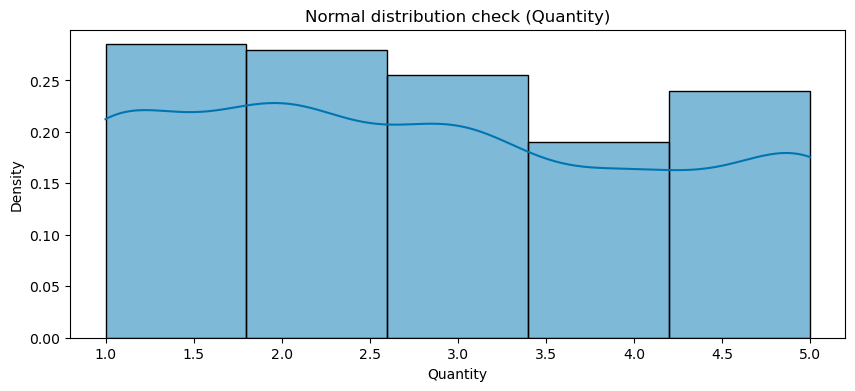

In [10]:
# Eksplorasi Data 7b
# Visualisasi distribusi data numerik (Quantity)
# menggunakan histogram untuk melihat pola persebaran data dan mengidentifikasi apakah distribusi cenderung normal atau tidak.
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,4))

sns.histplot(df_rf["Quantity"], bins=5, kde=True, stat="density", color="#0075b2")
plt.title("Normal distribution check (Quantity)")

plt.show()

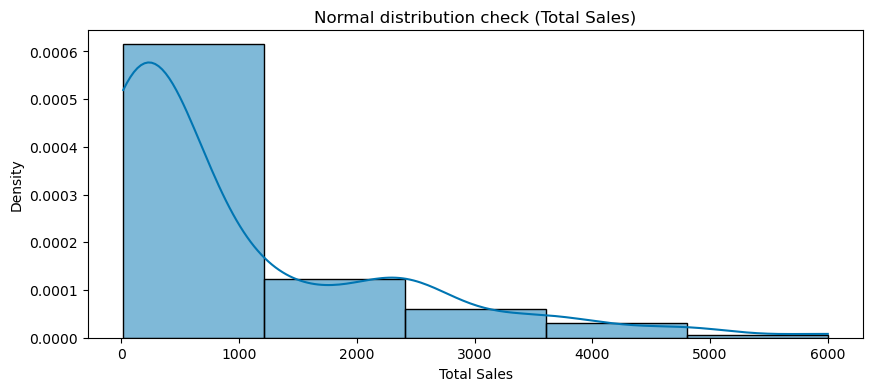

In [11]:
# Eksplorasi Data 7c
# Visualisasi distribusi data numerik (Total Sales)
# menggunakan histogram untuk melihat pola persebaran data dan mengidentifikasi apakah distribusi cenderung normal atau tidak.
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,4))

sns.histplot(df_rf["Total Sales"], bins=5, kde=True, stat="density", color="#0075b2")
plt.title("Normal distribution check (Total Sales)")

plt.show()

# mengecek konsistensi data kategorikal
Penulisan huruf besar/kecil, spasi berlebih, dan typo

In [12]:
# Eksplorasi Data 8
# Melakukan pengecekan kategori unik (unique values) pada atribut kategorikal untuk mengidentifikasi potensi inkonsistensi penulisan data.
for col in df_rf.select_dtypes(include="object").drop(columns="Date"):
    print(f"\nKolom: {col}")
    print(df_rf[col].unique())


Kolom: Order ID
['ORD0001' 'ORD0002' 'ORD0003' 'ORD0004' 'ORD0005' 'ORD0006' 'ORD0007'
 'ORD0008' 'ORD0009' 'ORD0010' 'ORD0011' 'ORD0012' 'ORD0013' 'ORD0014'
 'ORD0015' 'ORD0016' 'ORD0017' 'ORD0018' 'ORD0019' 'ORD0020' 'ORD0021'
 'ORD0022' 'ORD0023' 'ORD0024' 'ORD0025' 'ORD0026' 'ORD0027' 'ORD0028'
 'ORD0029' 'ORD0030' 'ORD0031' 'ORD0032' 'ORD0033' 'ORD0034' 'ORD0035'
 'ORD0036' 'ORD0037' 'ORD0038' 'ORD0039' 'ORD0040' 'ORD0041' 'ORD0042'
 'ORD0043' 'ORD0044' 'ORD0045' 'ORD0046' 'ORD0047' 'ORD0048' 'ORD0049'
 'ORD0050' 'ORD0051' 'ORD0052' 'ORD0053' 'ORD0054' 'ORD0055' 'ORD0056'
 'ORD0057' 'ORD0058' 'ORD0059' 'ORD0060' 'ORD0061' 'ORD0062' 'ORD0063'
 'ORD0064' 'ORD0065' 'ORD0066' 'ORD0067' 'ORD0068' 'ORD0069' 'ORD0070'
 'ORD0071' 'ORD0072' 'ORD0073' 'ORD0074' 'ORD0075' 'ORD0076' 'ORD0077'
 'ORD0078' 'ORD0079' 'ORD0080' 'ORD0081' 'ORD0082' 'ORD0083' 'ORD0084'
 'ORD0085' 'ORD0086' 'ORD0087' 'ORD0088' 'ORD0089' 'ORD0090' 'ORD0091'
 'ORD0092' 'ORD0093' 'ORD0094' 'ORD0095' 'ORD0096' 'ORD0097'

# mengecek konsistensi data numerikal
spasi berlebih

In [13]:
# Melakukan pengecekan jumlah kategori unik (unique values)
for col in df_rf.select_dtypes(include="object").drop(columns="Date"):
    print(f"\nKolom: {col}")
    print(df_rf[col].nunique())


Kolom: Order ID
250

Kolom: Product
10

Kolom: Category
5

Kolom: Customer Name
10

Kolom: Customer Location
10

Kolom: Payment Method
5

Kolom: Status
3


In [14]:
# Eksplorasi Data 9
# Melakukan pengecekan nilai unik pada atribut numerik bertipe integer untuk memahami variasi data
for col in df_rf.select_dtypes(include="int64"):
    print(f"\nKolom: {col}")
    print([f"{x}" for x in df_rf[col].unique()])


Kolom: Price
['60', '100', '150', '20', '500', '15', '40', '800', '600', '1200']

Kolom: Quantity
['3', '4', '2', '1', '5']

Kolom: Total Sales
['180', '400', '120', '450', '20', '600', '500', '60', '30', '160', '1600', '1800', '1200', '1000', '300', '4800', '15', '3600', '75', '100', '2000', '2400', '150', '80', '40', '240', '4000', '2500', '45', '750', '200', '1500', '3200', '6000', '3000', '800']


# 3.Data Cleaning

# Duplicate

In [15]:
# Data Cleaning 1
# Melakukan pengecekan ulang duplicate data untuk mengetahui apakah terdapat baris data yang sama (duplikat) pada dataset.
df_rf_clean = df_rf.copy()
total_duplicate = df_rf_clean.duplicated().sum()

if total_duplicate == 0:
    print("Tidak ditemukan data duplikat pada dataset.")
else:
    print(f"Ditemukan {total_duplicate} data duplikat pada dataset.")

Tidak ditemukan data duplikat pada dataset.


# Missing Value 

In [16]:
# Data Cleaning 2
# Melakukan pengecekan ulang missing values untuk memastikan tidak terdapat data kosong (null values) pada dataset.
total_missing_value = df_rf_clean.isnull().sum().sum()

if total_missing_value == 0:
    print("Tidak ditemukan missing values pada dataset.")
else:
    print(f"Ditemukan {total_missing_value} missing values pada dataset.")

Tidak ditemukan missing values pada dataset.


# Inkonsistensi Data

In [17]:
# Data Cleaning 3
# Melakukan penanganan terhadap potensi spasi berlebih (leading/trailing spaces) pada atribut bertipe object
# untuk menjaga konsistensi format data, meskipun pada tahap eksplorasi tidak ditemukan inkonsistensi yang signifikan.
df_rf_clean = df_rf_clean.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col)

# Validasi ulang atribut kategorikal setelah cleaning, untuk memastikan format data telah konsisten.
for col in df_rf_clean.select_dtypes(include= "object").drop(columns="Date"):
    print(f"\nKolom: {col}")
    print(df_rf_clean[col].unique())


Kolom: Order ID
['ORD0001' 'ORD0002' 'ORD0003' 'ORD0004' 'ORD0005' 'ORD0006' 'ORD0007'
 'ORD0008' 'ORD0009' 'ORD0010' 'ORD0011' 'ORD0012' 'ORD0013' 'ORD0014'
 'ORD0015' 'ORD0016' 'ORD0017' 'ORD0018' 'ORD0019' 'ORD0020' 'ORD0021'
 'ORD0022' 'ORD0023' 'ORD0024' 'ORD0025' 'ORD0026' 'ORD0027' 'ORD0028'
 'ORD0029' 'ORD0030' 'ORD0031' 'ORD0032' 'ORD0033' 'ORD0034' 'ORD0035'
 'ORD0036' 'ORD0037' 'ORD0038' 'ORD0039' 'ORD0040' 'ORD0041' 'ORD0042'
 'ORD0043' 'ORD0044' 'ORD0045' 'ORD0046' 'ORD0047' 'ORD0048' 'ORD0049'
 'ORD0050' 'ORD0051' 'ORD0052' 'ORD0053' 'ORD0054' 'ORD0055' 'ORD0056'
 'ORD0057' 'ORD0058' 'ORD0059' 'ORD0060' 'ORD0061' 'ORD0062' 'ORD0063'
 'ORD0064' 'ORD0065' 'ORD0066' 'ORD0067' 'ORD0068' 'ORD0069' 'ORD0070'
 'ORD0071' 'ORD0072' 'ORD0073' 'ORD0074' 'ORD0075' 'ORD0076' 'ORD0077'
 'ORD0078' 'ORD0079' 'ORD0080' 'ORD0081' 'ORD0082' 'ORD0083' 'ORD0084'
 'ORD0085' 'ORD0086' 'ORD0087' 'ORD0088' 'ORD0089' 'ORD0090' 'ORD0091'
 'ORD0092' 'ORD0093' 'ORD0094' 'ORD0095' 'ORD0096' 'ORD0097'

In [18]:
for col in df_rf_clean.select_dtypes(include='object').drop(columns="Date"):
    print(f"\nKolom: {col}")
    print(df_rf_clean[col].nunique())


Kolom: Order ID
250

Kolom: Product
10

Kolom: Category
5

Kolom: Customer Name
10

Kolom: Customer Location
10

Kolom: Payment Method
5

Kolom: Status
3


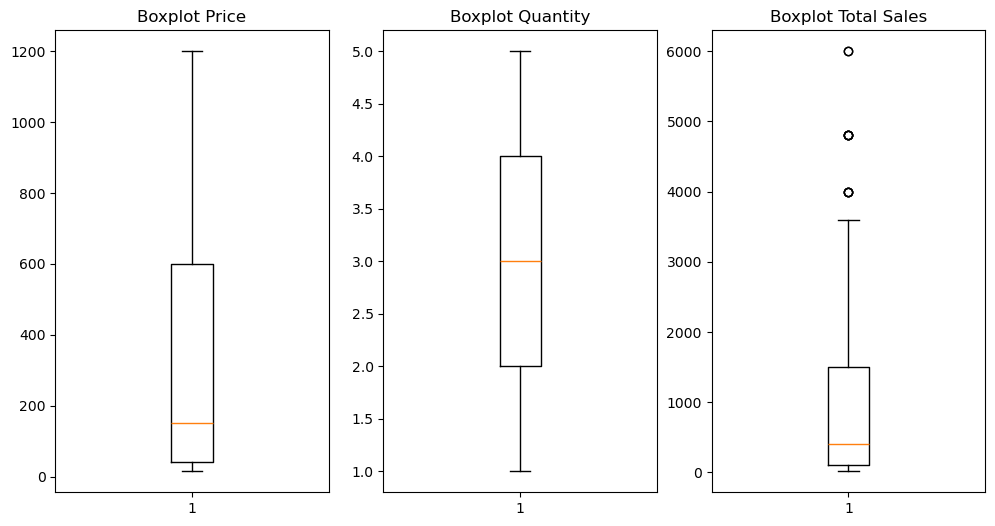

In [19]:
# Data Cleaning 4
# Melakukan visualisasi boxplot pada atribut numerik untuk mengidentifikasi potensi outlier pada data.
plt.figure(figsize=(12, 6))

# Boxplot Price
plt.subplot(1, 3, 1)
plt.boxplot(df_rf_clean["Price"])
plt.title("Boxplot Price")

# Boxplot Quantity
plt.subplot(1, 3, 2)
plt.boxplot(df_rf_clean["Quantity"])
plt.title("Boxplot Quantity")

# Boxplot Total Price
plt.subplot(1, 3, 3)
plt.boxplot(df_rf_clean["Total Sales"])
plt.title("Boxplot Total Sales")
plt.show() 

In [20]:
# Data Cleaning 4b
# Mengidentifikasi outlier pada atribut "Total Sales"
# menggunakan metode Interquartile Range (IQR).
Q1 = df_rf_clean["Total Sales"].quantile(0.25)
Q3 = df_rf_clean["Total Sales"].quantile(0.75)
IQR = Q3-Q1

# Menentukan batas bawah dan batas atas outlier
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

# Mengidentifikasi data outlier
outlier_iqr = df_rf_clean[(df_rf_clean["Total Sales"] < lower) | (df_rf_clean["Total Sales"] > upper)]
outlier_iqr

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
21,ORD0022,07-03-25,Refrigerator,Home Appliances,1200,4,4800,Olivia Wilson,Houston,Credit Card,Pending
61,ORD0062,10-02-25,Laptop,Electronics,800,5,4000,Olivia Wilson,San Francisco,PayPal,Completed
63,ORD0064,13-02-25,Refrigerator,Home Appliances,1200,4,4800,Emily Johnson,Denver,PayPal,Pending
68,ORD0069,25-02-25,Refrigerator,Home Appliances,1200,4,4800,David Lee,Boston,Gift Card,Pending
73,ORD0074,25-03-25,Refrigerator,Home Appliances,1200,4,4800,Jane Smith,Dallas,Gift Card,Cancelled
92,ORD0093,06-03-25,Refrigerator,Home Appliances,1200,5,6000,David Lee,Denver,PayPal,Cancelled
119,ORD0120,16-02-25,Laptop,Electronics,800,5,4000,Emily Johnson,Denver,PayPal,Completed
125,ORD0126,04-02-25,Refrigerator,Home Appliances,1200,5,6000,Olivia Wilson,Chicago,Gift Card,Pending
154,ORD0155,05-02-25,Refrigerator,Home Appliances,1200,4,4800,Sophia Miller,Seattle,Credit Card,Pending
167,ORD0168,24-03-25,Laptop,Electronics,800,5,4000,Michael Brown,Miami,Debit Card,Pending


In [21]:
# Data Cleaning 4c
# Evaluasi outlier pada atribut "Total Sales", untuk menentukan apakah diperlukan penanganan lebih lanjut.
jumlah_outlier = len(outlier_iqr)
print(f"Jumlah outlier: {jumlah_outlier}")

# Menghitung persentase outlier terhadap total data
persentase_outlier = (
    jumlah_outlier / len(df_rf_clean)) * 100

if persentase_outlier < 5:
    print(f"Persentase outlier: {persentase_outlier:.2f}%")
    print("Keputusan: Outlier dipertahankan karena jumlahnya relatif kecil.")
else:
    print(f"Persentase outlier: {persentase_outlier:.2f}%")
    print("Keputusan: Perlu evaluasi lebih lanjut terhadap outlier.")

Jumlah outlier: 11
Persentase outlier: 4.40%
Keputusan: Outlier dipertahankan karena jumlahnya relatif kecil.


# Outlier Labeling

In [22]:
# Data Cleaning 4d
# Memberikan label (flagging) pada data yang terindikasi sebagai outlier berdasarkan metode IQR pada atribut "Total Sales".
df_rf_clean["Is Outlier"] = (df_rf_clean["Total Sales"] < lower) | (df_rf_clean["Total Sales"] > upper)

# Menampilkan data yang terindikasi sebagai outlier
df_rf_clean[df_rf_clean["Is Outlier"]]

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Is Outlier
21,ORD0022,07-03-25,Refrigerator,Home Appliances,1200,4,4800,Olivia Wilson,Houston,Credit Card,Pending,True
61,ORD0062,10-02-25,Laptop,Electronics,800,5,4000,Olivia Wilson,San Francisco,PayPal,Completed,True
63,ORD0064,13-02-25,Refrigerator,Home Appliances,1200,4,4800,Emily Johnson,Denver,PayPal,Pending,True
68,ORD0069,25-02-25,Refrigerator,Home Appliances,1200,4,4800,David Lee,Boston,Gift Card,Pending,True
73,ORD0074,25-03-25,Refrigerator,Home Appliances,1200,4,4800,Jane Smith,Dallas,Gift Card,Cancelled,True
92,ORD0093,06-03-25,Refrigerator,Home Appliances,1200,5,6000,David Lee,Denver,PayPal,Cancelled,True
119,ORD0120,16-02-25,Laptop,Electronics,800,5,4000,Emily Johnson,Denver,PayPal,Completed,True
125,ORD0126,04-02-25,Refrigerator,Home Appliances,1200,5,6000,Olivia Wilson,Chicago,Gift Card,Pending,True
154,ORD0155,05-02-25,Refrigerator,Home Appliances,1200,4,4800,Sophia Miller,Seattle,Credit Card,Pending,True
167,ORD0168,24-03-25,Laptop,Electronics,800,5,4000,Michael Brown,Miami,Debit Card,Pending,True


# 4.Data Manipulation

# Uji Normalitas Data Setelah Cleaning (Price, Quantity, Total Sales)

Metode Original     | P-Value: 0.00000000000000001067
Metode Square Root  | P-Value: 0.00000000000009210817
Metode Log          | P-Value: 0.00000000004635436403
Metode Box-Cox      | P-Value: 0.00000000005124604080


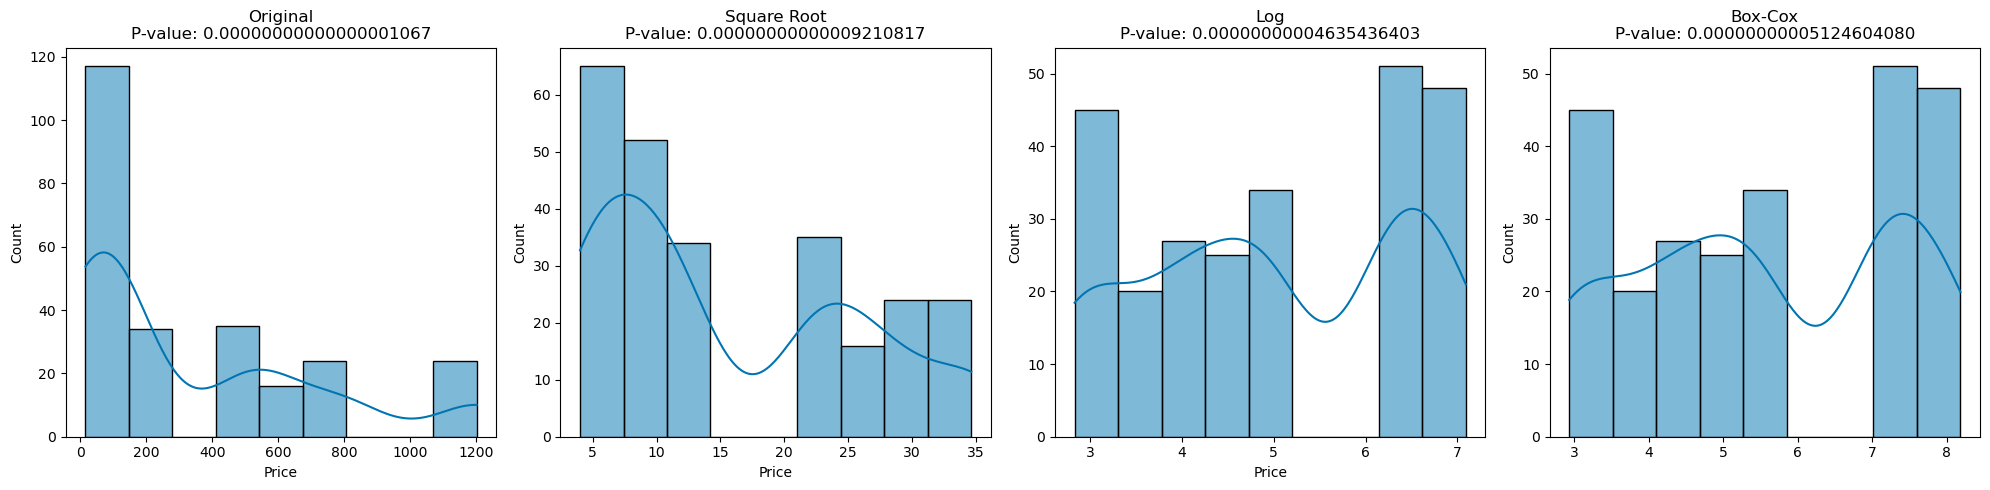

Metode Original     | P-Value: 0.00000000000044905683
Metode Square Root  | P-Value: 0.00000000000064160972
Metode Log          | P-Value: 0.00000000000038759299
Metode Box-Cox      | P-Value: 0.00000000000056707047


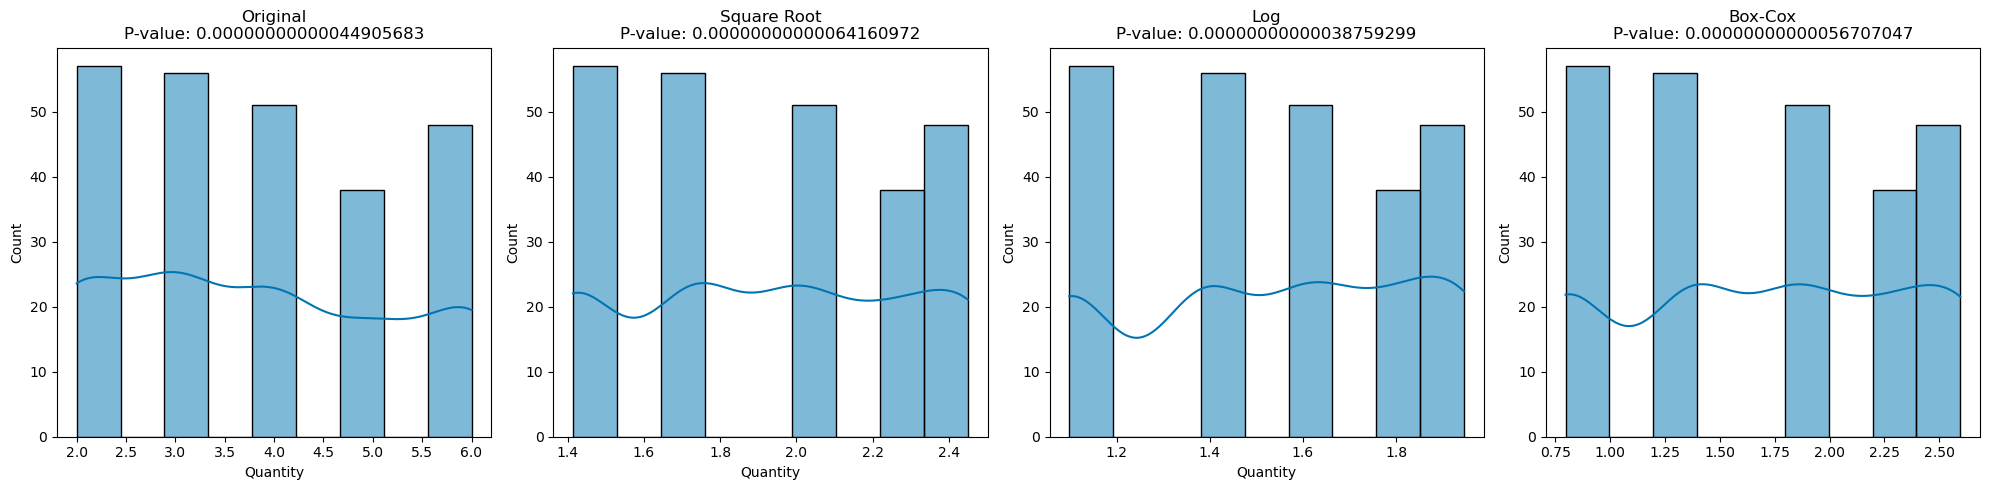

Metode Original     | P-Value: 0.00000000000000000051
Metode Square Root  | P-Value: 0.00000000000394586888
Metode Log          | P-Value: 0.00000661038211918064
Metode Box-Cox      | P-Value: 0.00001282173116767115


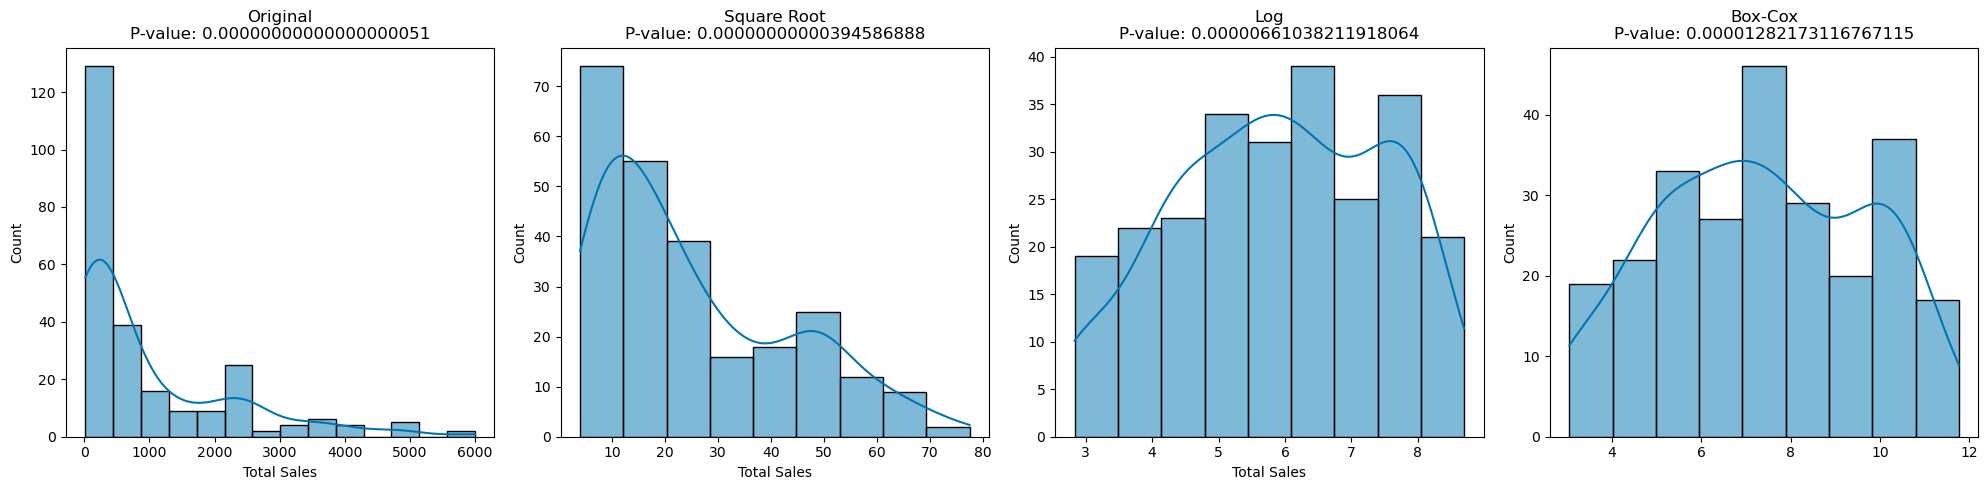

In [23]:
import numpy as np
import scipy.stats as stats

def try_transformations(df_rf, column):
    
    # 1. Siapkan data_ori (Menambahkan nilai 1 untuk menghindari log(0) atau boxcox(0))
    data_ori = df_rf[column] + 1

    # Metode transformasi
    data_sqrt = np.sqrt(data_ori) # Metode Square Root
    data_log = np.log1p(data_ori) # Metode Log Transformation
    
    # Box-Cox transformation
    # Box-cox mengembalikan data dan nilai lambda optimal
    data_boxcox, lam = stats.boxcox(data_ori)
    
    # List untuk looping visualisasi
    methods = [
        ("Original", data_ori),
        ("Square Root", data_sqrt),
        ("Log", data_log),
        ("Box-Cox", data_boxcox)
    ]
    
    # Visualisasi Perbandingan
    plt.figure(figsize=(20, 5))
    
    for i, (name, data) in enumerate(methods):
        plt.subplot(1, 4, i+1)
        sns.histplot(data, kde=True, color="#0075b2")
        
        # Hitung Shapiro-Wilk
        stat, p = stats.shapiro(data)
        plt.title(f"{name}\nP-value: {p:.20f}")
        print(f"Metode {name:12} | P-Value: {p:.20f}")
    
    plt.tight_layout()
    plt.show()

kolom_numerik = ["Price", "Quantity", "Total Sales"]

for col in kolom_numerik:
    try_transformations(df_rf_clean, col)

In [35]:
# Berdasarkan hasil uji normalisasi data,diketahui bahwa distribusi data masih cenderung tidak normal 
# meskipun telah dilakukan pengujian menggunakan tiga metode yaitu Square Root, Log Transformation,dan Box-Cox.

# Data Type Conversion

In [25]:
# Data Manipulation 1
# Melakukan type conversion pada atribut "Date" dari object menjadi datetime agar dapat digunakan untuk analisis berbasis waktu.
df_rf_manipulation = df_rf_clean.copy()

df_rf_manipulation["Date"] = pd.to_datetime(df_rf_manipulation["Date"], format="%d-%m-%y", errors="coerce")
df_rf_manipulation.head(10)

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Is Outlier
0,ORD0001,2025-03-14,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled,False
1,ORD0002,2025-03-20,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending,False
2,ORD0003,2025-02-15,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled,False
3,ORD0004,2025-02-19,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending,False
4,ORD0005,2025-03-10,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending,False
5,ORD0006,2025-03-14,T-Shirt,Clothing,20,1,20,John Doe,Dallas,Credit Card,Pending,False
6,ORD0007,2025-03-18,Smartwatch,Electronics,150,4,600,Emma Clark,Houston,PayPal,Completed,False
7,ORD0008,2025-03-02,Smartphone,Electronics,500,1,500,Sophia Miller,Miami,PayPal,Completed,False
8,ORD0009,2025-03-08,T-Shirt,Clothing,20,3,60,Sophia Miller,Boston,PayPal,Completed,False
9,ORD0010,2025-03-12,Smartphone,Electronics,500,1,500,Emily Johnson,San Francisco,Credit Card,Cancelled,False


In [58]:
# Memastikan tipe data atribut "Date"
print("Tipe data kolom Date:")
print(df_rf_manipulation["Date"].dtype)
# telah berhasil dikonversi menjadi datetime.

Tipe data kolom Date:
datetime64[ns]


In [59]:
df_rf_manipulation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           250 non-null    object        
 1   Date               250 non-null    datetime64[ns]
 2   Product            250 non-null    object        
 3   Category           250 non-null    object        
 4   Price              250 non-null    int64         
 5   Quantity           250 non-null    int64         
 6   Total Sales        250 non-null    int64         
 7   Customer Name      250 non-null    object        
 8   Customer Location  250 non-null    object        
 9   Payment Method     250 non-null    object        
 10  Status             250 non-null    object        
 11  Is Outlier         250 non-null    bool          
dtypes: bool(1), datetime64[ns](1), int64(3), object(7)
memory usage: 21.9+ KB


# Data Filtering dan Sorting

In [27]:
# Data Manipulation 2
# Filtering data berdasarkan transaksi dengan Total Sales di atas nilai median.
median_total_sales = (df_rf_manipulation["Total Sales"].median()) # Menggunakan median sebagai nilai acuan filtering
# karena distribusi data tidak normal dan terdapat outlier pada atribut Total Sales.
print(f"Median Total Sales: {median_total_sales}")

# Filtering transaksi dengan sales tinggi
high_sales = df_rf_manipulation[df_rf_manipulation["Total Sales"]> median_total_sales]

# Sorting data berdasarkan Total Sales
high_sales = high_sales.sort_values(by="Total Sales",ascending=False)

high_sales.head()

Median Total Sales: 400.0


,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Is Outlier
92,ORD0093,2025-03-06,Refrigerator,Home Appliances,1200,5,6000,David Lee,Denver,PayPal,Cancelled,True
125,ORD0126,2025-02-04,Refrigerator,Home Appliances,1200,5,6000,Olivia Wilson,Chicago,Gift Card,Pending,True
154,ORD0155,2025-02-05,Refrigerator,Home Appliances,1200,4,4800,Sophia Miller,Seattle,Credit Card,Pending,True
73,ORD0074,2025-03-25,Refrigerator,Home Appliances,1200,4,4800,Jane Smith,Dallas,Gift Card,Cancelled,True
21,ORD0022,2025-03-07,Refrigerator,Home Appliances,1200,4,4800,Olivia Wilson,Houston,Credit Card,Pending,True


In [28]:
# Data Manipulation 3
# Filtering transaksi dengan status Completed kemudian diurutkan berdasarkan Total Sales tertinggi.
jumlah_transaksi = len(high_sales)
jumlah_transaksi = high_sales.shape[0]
print(f"Jumlah transaksi dengan penjualan tinggi: {jumlah_transaksi}")

completed_order = (df_rf_manipulation[df_rf_manipulation["Status"] == "Completed"].sort_values(by="Total Sales",ascending=False))
completed_order.head()

Jumlah transaksi dengan penjualan tinggi: 121


,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Is Outlier
119,ORD0120,2025-02-16,Laptop,Electronics,800,5,4000,Emily Johnson,Denver,PayPal,Completed,True
61,ORD0062,2025-02-10,Laptop,Electronics,800,5,4000,Olivia Wilson,San Francisco,PayPal,Completed,True
202,ORD0203,2025-02-21,Refrigerator,Home Appliances,1200,3,3600,John Doe,Dallas,Debit Card,Completed,False
207,ORD0208,2025-02-02,Refrigerator,Home Appliances,1200,3,3600,John Doe,Miami,PayPal,Completed,False
231,ORD0232,2025-03-14,Refrigerator,Home Appliances,1200,3,3600,Emma Clark,Los Angeles,Credit Card,Completed,False


In [29]:
# Data Manipulation 4
# Filtering dilakukan untuk memilih transaksi dengan status "Completed" 
# agar analisis hanya berfokus pada transaksi yang valid dan benar-benar berhasil diproses.

# Memfilter transaksi dengan status Completed
completed_order = df_rf_manipulation[df_rf_manipulation["Status"] == "Completed"]

# Menghitung jumlah transaksi completed
jumlah_completed = completed_order.shape[0]

# Menghitung total transaksi pada dataset
total_transaksi = df_rf_manipulation.shape[0]

# Menghitung persentase transaksi completed
persentase_completed = (jumlah_completed / total_transaksi) * 100

# Menampilkan jumlah dan persentase
# transaksi completed terhadap total data
print(
    f"Jumlah transaksi completed: "
    f"{jumlah_completed} dari "
    f"{total_transaksi} transaksi "
    f"({persentase_completed:.2f}%)"
)

Jumlah transaksi completed: 88 dari 250 transaksi (35.20%)


In [67]:
# Data Manipulation 4b
# Filtering dilakukan untuk memilih transaksi dengan status "Tidak Completed (Pending dan Cancelled)" 

# Memfilter transaksi dengan status Tidak Completed (Pending dan Cancelled)
Non_completed_order = df_rf_manipulation[df_rf_manipulation["Status"].isin(["Pending", "Cancelled"])]

# Menghitung jumlah transaksi completed
jumlah_Non_completed = Non_completed_order.shape[0]

# Menghitung total transaksi pada dataset
total_transaksi = df_rf_manipulation.shape[0]

# Menghitung persentase transaksi completed
persentase_Non_completed = (jumlah_Non_completed / total_transaksi) * 100

# Menampilkan jumlah dan persentase
# transaksi completed terhadap total data
print(
    f"Jumlah transaksi non-completed: "
    f"{jumlah_Non_completed} dari "
    f"{total_transaksi} transaksi "
    f"({persentase_Non_completed:.2f}%)"
)

Jumlah transaksi non-completed: 162 dari 250 transaksi (64.80%)


In [30]:
# Data Manipulation 5
# Filtering dilakukan untuk memilih transaksi yang berstatus "Completed" dengan nilai Total Sales di atas nilai median (400).
# Hal ini bertujuan untuk mengidentifikasi transaksi bernilai tinggi yang berhasil diproses.

# Memfilter transaksi dengan dua kondisi:
# Status = "Completed" dan Total Sales > median (400)
completed_high_sales = df_rf_manipulation[(df_rf_manipulation["Status"] == "Completed") & (df_rf_manipulation["Total Sales"] > median_total_sales)]

# Menghitung jumlah transaksi yang memenuhi kondisi filter
jumlah_data = completed_high_sales.shape[0]

# Mengurutkan transaksi berdasarkan Total Sales tertinggi agar lebih mudah dianalisis
completed_high_sales_sorted = (completed_high_sales.sort_values(by="Total Sales",ascending=False))

# Menampilkan jumlah transaksi yang memenuhi kriteria filtering
print(
    f"Ditemukan {jumlah_data} transaksi "
    f"berstatus 'Completed' dengan "
    f"penjualan di atas nilai median (400)."
)

# Menampilkan hasil filtering
display(completed_high_sales_sorted)

Ditemukan 46 transaksi berstatus 'Completed' dengan penjualan di atas nilai median (400).


,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Is Outlier
119,ORD0120,2025-02-16,Laptop,Electronics,800,5,4000,Emily Johnson,Denver,PayPal,Completed,True
61,ORD0062,2025-02-10,Laptop,Electronics,800,5,4000,Olivia Wilson,San Francisco,PayPal,Completed,True
179,ORD0180,2025-03-04,Refrigerator,Home Appliances,1200,3,3600,David Lee,Boston,Gift Card,Completed,False
202,ORD0203,2025-02-21,Refrigerator,Home Appliances,1200,3,3600,John Doe,Dallas,Debit Card,Completed,False
231,ORD0232,2025-03-14,Refrigerator,Home Appliances,1200,3,3600,Emma Clark,Los Angeles,Credit Card,Completed,False
207,ORD0208,2025-02-02,Refrigerator,Home Appliances,1200,3,3600,John Doe,Miami,PayPal,Completed,False
110,ORD0111,2025-03-31,Laptop,Electronics,800,4,3200,Emma Clark,Los Angeles,Credit Card,Completed,False
115,ORD0116,2025-03-19,Laptop,Electronics,800,4,3200,Emma Clark,Los Angeles,Amazon Pay,Completed,False
98,ORD0099,2025-02-18,Washing Machine,Home Appliances,600,5,3000,Michael Brown,Seattle,Debit Card,Completed,False
235,ORD0236,2025-03-05,Smartphone,Electronics,500,5,2500,John Doe,Boston,PayPal,Completed,False


In [31]:
# Data Manipulation 6
# Grouping dilakukan untuk mengetahui kontribusi total penjualan berdasarkan kategori produk.

# Menghitung total sales per kategori
sales_category = (df_rf_manipulation.groupby("Category")["Total Sales"].sum().sort_values(ascending=False))

# Menghitung persentase kontribusi
kontribusi_sales = (sales_category /sales_category.sum()) * 100

# Membulatkan hasil menjadi 2 digit
kontribusi_sales = kontribusi_sales.round(2)

# Menampilkan kontribusi penjualan tiap kategori produk
kontribusi_sales

Category
Electronics        53.29
Home Appliances    43.06
Footwear            1.77
Clothing            1.45
Books               0.42
Name: Total Sales, dtype: float64

In [32]:
# Data Manipulation 6b
# Grouping dilakukan untuk mengetahui kontribusi total penjualan berdasarkan kategori produk.
# berfokus pada analisis kontribusi penjualan berdasarkan transaksi yang valid / completed.

# Memfilter transaksi completed
completed_order = df_rf_manipulation[df_rf_manipulation["Status"] == "Completed"]

# Menghitung total sales per kategori
sales_category = (completed_order.groupby("Category")["Total Sales"].sum().sort_values(ascending=False))

# Menghitung persentase kontribusi total penjualan tiap kategori
kontribusi_sales = (sales_category /sales_category.sum()) * 100

# Membulatkan hasil menjadi 2 digit
kontribusi_sales = kontribusi_sales.round(2)

# Menampilkan kontribusi penjualan kategori produk pada transaksi completed
kontribusi_sales

Category
Electronics        63.14
Home Appliances    33.21
Footwear            1.83
Clothing            1.58
Books               0.24
Name: Total Sales, dtype: float64

#  feature engineering 

In [60]:
# Data Manipulation 7
# Feature engineering dilakukan untuk mengelompokkan transaksi berdasarkan nilai Total Sales menjadi kategori penjualan tinggi dan rendah.

# Membuat dataset baru agar data asli tetap aman dan tidak berubah
df_rf_manipulation2 = (df_rf_manipulation.copy())

# Membuat kategori penjualan berdasarkan nilai median Total Sales
# > median = High Sales
# <= median = Low Sales
df_rf_manipulation2["Sales Category"] = df_rf_manipulation2["Total Sales"].apply(
    lambda x: "High Sales" if x > median_total_sales else "Low Sales")

# Menampilkan 5 data pertama setelah penambahan kolom baru
df_rf_manipulation2.head(5)

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Is Outlier,Sales Category
0,ORD0001,2025-03-14,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled,False,Low Sales
1,ORD0002,2025-03-20,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending,False,Low Sales
2,ORD0003,2025-02-15,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled,False,Low Sales
3,ORD0004,2025-02-19,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending,False,Low Sales
4,ORD0005,2025-03-10,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending,False,High Sales


# Encoding 

In [61]:
# Data Encoding 
# Encoding dilakukan untuk mengubah data kategorikal menjadi numerik agar dapat digunakan untuk analisis lanjutan.

from sklearn.preprocessing import LabelEncoder
from category_encoders import BinaryEncoder

# Membuat dataset baru agar data sebelumnya tetap aman dan tidak berubah
df_rf_encoding = (df_rf_manipulation2.copy())

# Order ID - Binary Encoding
# Binary Encoding dilakukan pada Order ID karena memiliki banyak kategori unik.

encoder = BinaryEncoder(cols=["Order ID"])

df_rf_encoding = (
    encoder.fit_transform(df_rf_encoding)
)

# Product - Frequency Encoding
# Frequency Encoding dilakukan pada Product karena memiliki banyak kategori unik (high cardinality).
# Metode ini dipilih agar jumlah kolom tetap efisien dan tidak membuat dataset terlalu besar,
# sekaligus tetap mempertahankan informasi berdasarkan frekuensi kemunculan produk.

freq_product = (
    df_rf_encoding["Product"]
    .value_counts(normalize=True)
)

df_rf_encoding["Product"] = (
    df_rf_encoding["Product"]
    .map(freq_product)
)

# Customer Name - Label Encoding
# Label Encoding dilakukan pada Customer Name karena jumlah kategori relatif sedikit.

le = LabelEncoder()

df_rf_encoding["Customer Name"] = (
    le.fit_transform(df_rf_encoding["Customer Name"])
)

# Customer Location - Binary Encoding
# Binary Encoding dilakukan pada Customer Location karena memiliki banyak kategori unik.

encoder = BinaryEncoder(cols=["Customer Location"])

df_rf_encoding = (
    encoder.fit_transform(df_rf_encoding)
)

# Is Outlier & Sales Category - Label Encoding
# Label Encoding dilakukan karena hanya memiliki dua kategori.

df_rf_encoding["Is Outlier"] = (
    le.fit_transform(df_rf_encoding["Is Outlier"])
)

df_rf_encoding["Sales Category"] = (
    le.fit_transform(df_rf_encoding["Sales Category"])
)

# Melakukan One Hot Encoding pada kolom Category, Payment Method, dan Status
# One Hot Encoding dilakukan karena tidak memiliki urutan alami.

df_rf_encoding = pd.get_dummies(
    df_rf_encoding,
    columns=[
        "Category",
        "Payment Method",
        "Status"
    ],
    drop_first=False
)

# Menampilkan 3 data pertama setelah seluruh proses encoding
df_rf_encoding.head(3)

,Order ID_0,Order ID_1,Order ID_2,Order ID_3,Order ID_4,Order ID_5,Order ID_6,Order ID_7,Date,Product,...,Category_Footwear,Category_Home Appliances,Payment Method_Amazon Pay,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_Gift Card,Payment Method_PayPal,Status_Cancelled,Status_Completed,Status_Pending
0,0,0,0,0,0,0,0,1,2025-03-14,0.108,...,True,False,False,False,True,False,False,True,False,False
1,0,0,0,0,0,0,1,0,2025-03-20,0.100,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,0,0,0,1,1,2025-02-15,0.108,...,True,False,True,False,False,False,False,True,False,False


# Final Output

In [62]:
# Final Output
# Membuat dataset akhir setelah seluruh proses preprocessing dan encoding selesai dilakukan.
final_df_rf = df_rf_encoding.copy()

# Menampilkan informasi dataset akhir
final_df_rf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Order ID_0                  250 non-null    int64         
 1   Order ID_1                  250 non-null    int64         
 2   Order ID_2                  250 non-null    int64         
 3   Order ID_3                  250 non-null    int64         
 4   Order ID_4                  250 non-null    int64         
 5   Order ID_5                  250 non-null    int64         
 6   Order ID_6                  250 non-null    int64         
 7   Order ID_7                  250 non-null    int64         
 8   Date                        250 non-null    datetime64[ns]
 9   Product                     250 non-null    float64       
 10  Price                       250 non-null    int64         
 11  Quantity                    250 non-null    int64         

In [63]:
# Menampilkan ukuran dataset akhir
row, col = final_df_rf.shape
print(f"Terdapat {row} Baris dan {col} Kolom")

Terdapat 250 Baris dan 33 Kolom


In [64]:
# Menampilkan 10 data pertama dataset akhir
final_df_rf.head(10)

,Order ID_0,Order ID_1,Order ID_2,Order ID_3,Order ID_4,Order ID_5,Order ID_6,Order ID_7,Date,Product,...,Category_Footwear,Category_Home Appliances,Payment Method_Amazon Pay,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_Gift Card,Payment Method_PayPal,Status_Cancelled,Status_Completed,Status_Pending
0,0,0,0,0,0,0,0,1,2025-03-14,0.108,...,True,False,False,False,True,False,False,True,False,False
1,0,0,0,0,0,0,1,0,2025-03-20,0.100,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,0,0,0,1,1,2025-02-15,0.108,...,True,False,True,False,False,False,False,True,False,False
3,0,0,0,0,0,1,0,0,2025-02-19,0.108,...,True,False,False,True,False,False,False,False,False,True
4,0,0,0,0,0,1,0,1,2025-03-10,0.136,...,False,False,False,False,True,False,False,False,False,True
5,0,0,0,0,0,1,1,0,2025-03-14,0.080,...,False,False,False,True,False,False,False,False,False,True
6,0,0,0,0,0,1,1,1,2025-03-18,0.136,...,False,False,False,False,False,False,True,False,True,False
7,0,0,0,0,1,0,0,0,2025-03-02,0.140,...,False,False,False,False,False,False,True,False,True,False
8,0,0,0,0,1,0,0,1,2025-03-08,0.080,...,False,False,False,False,False,False,True,False,True,False
9,0,0,0,0,1,0,1,0,2025-03-12,0.140,...,False,False,False,True,False,False,False,True,False,False
